<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Aprendizado_de_Maq.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Processamento de Linguagem Natural

## Aprendizado de Máquina

### Construindo Detector de Fake News

Vamos utilizar aprendizado de máquina supervisionado para construir um classificador/detector de fake news

* Coleta dos dados
* Representação

  * Bag of Words
  * TFIDF

* Aprendizado de máquina com scikit-learn
  * Treinamento
  * Avaliação
  * Interpretação de conhecimento adquirido
  

In [1]:
!pip install graphviz matplotlib scikit-learn
import pandas as pd
import numpy as np

# Coleta dos dados

In [3]:
!wget https://s3.amazonaws.com/assets.datacamp.com/production/course_3629/fake_or_real_news.csv -O fake_or_real_news.csv
df = pd.read_csv('fake_or_real_news.csv')
df.head()

--2026-02-27 22:08:33--  https://s3.amazonaws.com/assets.datacamp.com/production/course_3629/fake_or_real_news.csv
Resolving s3.amazonaws.com (s3.amazonaws.com)... 16.15.183.216, 52.216.34.16, 52.217.122.96, ...
Connecting to s3.amazonaws.com (s3.amazonaws.com)|16.15.183.216|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 30696129 (29M) [text/csv]
Saving to: ‘fake_or_real_news.csv’

fake_or_real_news.c 100%[===================>]  29.27M  29.6MB/s    in 1.0s    

2026-02-27 22:08:34 (29.6 MB/s) - ‘fake_or_real_news.csv’ saved [30696129/30696129]



,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


In [4]:
df[['label']].describe()

,label
count,6335
unique,2
top,REAL
freq,3171


# Representação

## Utilizando o CountVectorizer

In [5]:
from itertools import count
from re import X
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

y = df.label

X_train, X_test, y_train, y_test = train_test_split(df['text'], y,
                                                    test_size=0.33, random_state=53)

count_vectorizer = CountVectorizer(stop_words='english')
count_train = count_vectorizer.fit_transform(X_train)
count_test = count_vectorizer.transform(X_test)

print(count_vectorizer.get_feature_names_out()[:10])
print("Treino: ", count_train.toarray().shape)
print("Teste: ", count_test.toarray().shape)

['00' '000' '0000' '00000031' '000035' '00006' '0001' '0001pt' '000ft'
 '000km']
Treino:  (4244, 56922)
Teste:  (2091, 56922)


# Utilizando o TFIDFVectorizer

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)
tfidf_train = tfidf_vectorizer.fit_transform(X_train)
tfidf_test = tfidf_vectorizer.transform(X_test)

print(tfidf_vectorizer.get_feature_names_out()[:10])
print(tfidf_train.toarray()[:5])

print("Treino: ", tfidf_train.toarray().shape)
print("Teste: ", tfidf_test.toarray().shape)

['00' '000' '0000' '00000031' '000035' '00006' '0001' '0001pt' '000ft'
 '000km']
[[0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]]
Treino:  (4244, 56922)
Teste:  (2091, 56922)


## Inspecionando os vetores

Utilizando DataFrames, vamos dar uma olhada em como ficaram os vetores

In [9]:
count_df = pd.DataFrame(count_train.toarray(), columns=count_vectorizer.get_feature_names_out())

tfidf_df = pd.DataFrame(tfidf_train.toarray(), columns=tfidf_vectorizer.get_feature_names_out())

print("Count_df:")
print(count_df.head())
print()

print("Tfidf_df:")
print(tfidf_df.head())

difference = set(count_df.columns) - set(tfidf_df.columns)
print(difference)

print()
print("Os DataFrames são iguais? ", count_df.equals(tfidf_df))

print()
print("# features count: ", count_df.columns.size)
print("# features tfidf: ", tfidf_df.columns.size)

Count_df:
   00  000  0000  00000031  000035  00006  0001  0001pt  000ft  000km  ...  \
0   0    0     0         0       0      0     0       0      0      0  ...   
1   0    0     0         0       0      0     0       0      0      0  ...   
2   0    0     0         0       0      0     0       0      0      0  ...   
3   0    0     0         0       0      0     0       0      0      0  ...   
4   0    0     0         0       0      0     0       0      0      0  ...   

   حلب  عربي  عن  لم  ما  محاولات  من  هذا  والمرضى  ยงade  
0    0     0   0   0   0        0   0    0        0      0  
1    0     0   0   0   0        0   0    0        0      0  
2    0     0   0   0   0        0   0    0        0      0  
3    0     0   0   0   0        0   0    0        0      0  
4    0     0   0   0   0        0   0    0        0      0  

[5 rows x 56922 columns]

Tfidf_df:
    00  000  0000  00000031  000035  00006  0001  0001pt  000ft  000km  ...  \
0  0.0  0.0   0.0       0.0     0.0    

# Aprendizado de Máquina com scikit-learn

Começaremos o processo de treinamento e teste de um classificador/detector de fake news utilizando as duas representações diferentes que construímos.

Inicialmente, vamos criar a função plot_confusion_matrix que, resumidamente, apresenta os resultados obtidos pelos classificadores.

In [10]:
import matplotlib as mpl
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import itertools
from sklearn.metrics import roc_auc_score

In [11]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
  if normalize:
    cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

  plt.imshow(cm, interpolation='nearest', cmap=cmap)
  plt.title(title)
  plt.colorbar()
  tick_marks = np.arange(len(classes))
  plt.xticks(tick_marks, classes, rotation=45)
  plt.yticks(tick_marks, classes)

  fmt = '.2f' if normalize else 'd'
  thresh = cm.max() / 2.
  for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    plt.text(j, i, format(cm[i, j], fmt),
             horizontalalignment="center",
             color="white" if cm[i, j] > thresh else "black")

  plt.tight_layout()
  plt.ylabel('Observado ', fontsize=15)
  plt.xlabel('Previsto ', fontsize=15)

# Treinando e testando o modelo detector de fake news com o CountVectorizer

In [12]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix

Acurácia:  0.893352462936394 

Matriz de confusão
 [[ 865  143]
 [  80 1003]] 

ROC_AOC_Score:  0.9337112884550558 



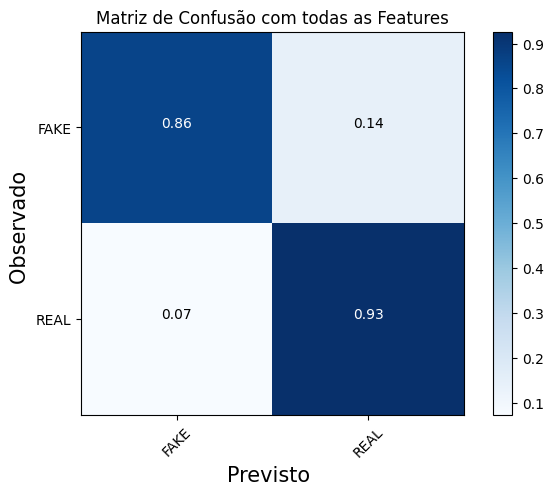

In [13]:
nb_classifier = MultinomialNB()
nb_classifier.fit(count_train, y_train)

pred = nb_classifier.predict(count_test)

score = accuracy_score(y_test, pred)
print("Acurácia: ", score, "\n")

cm = confusion_matrix(y_test, pred, labels=['FAKE', 'REAL'])
print("Matriz de confusão\n", cm, "\n")

plot_confusion_matrix(cm, classes=['FAKE', 'REAL'], normalize=True,
                      title='Matriz de Confusão com todas as Features')

y_pred_prob = nb_classifier.predict_proba(count_test)[:, 1]
print("ROC_AOC_Score: ", roc_auc_score(y_test, y_pred_prob), "\n")

# Treinando e testando o modelo com TFIDFVectorizer

Acurácia:  0.8565279770444764 

Matriz de confusão
 [[ 739  269]
 [  31 1052]] 

ROC_AOC_Score:  0.9619324260944759 



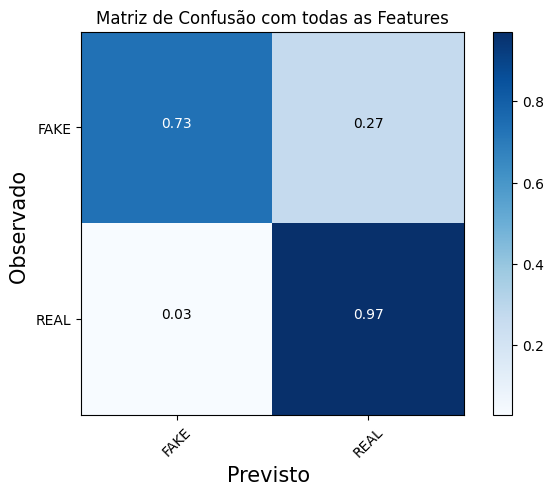

In [14]:
nb_classifier = MultinomialNB()
nb_classifier.fit(tfidf_train, y_train)
pred = nb_classifier.predict(tfidf_test)

score = accuracy_score(y_test, pred)
print("Acurácia: ", score, "\n")

cm = confusion_matrix(y_test, pred, labels=["FAKE", "REAL"])
print("Matriz de confusão\n", cm, "\n")

plot_confusion_matrix(cm, classes=["FAKE", "REAL"], normalize=True,
                      title="Matriz de Confusão com todas as Features")

y_pred_prob = nb_classifier.predict_proba(tfidf_test)[:, 1]
print("ROC_AOC_Score: ", roc_auc_score(y_test, y_pred_prob),"\n")

# Ajsutando parâmetros do modelo

In [16]:
alphas = np.arange(0, 1, 0.1)

def train_and_predict(alpha):
  nb_classifier = MultinomialNB(alpha=alpha, force_alpha=True)
  nb_classifier.fit(tfidf_train, y_train)
  pred = nb_classifier.predict(tfidf_test)
  score = accuracy_score(y_test, pred)
  return score

for alpha in alphas:
  print("Alpha: ", alpha)
  print("Score: ", train_and_predict(alpha), "\n")
  print()

Alpha:  0.0
Score:  0.6150167384026781 


Alpha:  0.1
Score:  0.8976566236250598 


Alpha:  0.2
Score:  0.8938307030129125 


Alpha:  0.30000000000000004
Score:  0.8900047824007652 


Alpha:  0.4
Score:  0.8857006217120995 


Alpha:  0.5
Score:  0.8842659014825442 


Alpha:  0.6000000000000001
Score:  0.874701099952176 


Alpha:  0.7000000000000001
Score:  0.8703969392635102 


Alpha:  0.8


/usr/local/lib/python3.12/dist-packages/sklearn/naive_bayes.py:898: RuntimeWarning: divide by zero encountered in log
  self.feature_log_prob_ = np.log(smoothed_fc) - np.log(


Score:  0.8660927785748446 


Alpha:  0.9
Score:  0.8589191774270684 




# Interpretando o Modelo

In [17]:
class_labels = nb_classifier.classes_
feature_names = tfidf_vectorizer.get_feature_names_out()

feat_with_weights = sorted(zip(nb_classifier.feature_log_prob_[0], feature_names))

print(class_labels[0], feat_with_weights[:20])
print(class_labels[1], feat_with_weights[-20:])

FAKE [(np.float64(-11.280753302177917), '00000031'), (np.float64(-11.280753302177917), '00006'), (np.float64(-11.280753302177917), '000ft'), (np.float64(-11.280753302177917), '001'), (np.float64(-11.280753302177917), '002'), (np.float64(-11.280753302177917), '003'), (np.float64(-11.280753302177917), '006'), (np.float64(-11.280753302177917), '008'), (np.float64(-11.280753302177917), '010'), (np.float64(-11.280753302177917), '013'), (np.float64(-11.280753302177917), '025'), (np.float64(-11.280753302177917), '027'), (np.float64(-11.280753302177917), '035'), (np.float64(-11.280753302177917), '037'), (np.float64(-11.280753302177917), '040'), (np.float64(-11.280753302177917), '044'), (np.float64(-11.280753302177917), '048'), (np.float64(-11.280753302177917), '066'), (np.float64(-11.280753302177917), '068'), (np.float64(-11.280753302177917), '075')]
REAL [(np.float64(-8.036772745824805), 'president'), (np.float64(-8.022187159522364), 'american'), (np.float64(-8.013319806154511), 'media'), (np

# Utilizando outro classificador - Árvores de Decisão

Acurácia:  0.7527498804399809 

Matriz de confusão
 [[814 194]
 [323 760]] 

|--- feature_44108 <= 0.04
|   |--- feature_42534 <= 0.01
|   |   |--- feature_649 <= 0.00
|   |   |   |--- class: FAKE
|   |   |--- feature_649 >  0.00
|   |   |   |--- class: FAKE
|   |--- feature_42534 >  0.01
|   |   |--- feature_16972 <= 0.07
|   |   |   |--- class: REAL
|   |   |--- feature_16972 >  0.07
|   |   |   |--- class: FAKE
|--- feature_44108 >  0.04
|   |--- feature_35716 <= 0.02
|   |   |--- feature_52298 <= 0.04
|   |   |   |--- class: REAL
|   |   |--- feature_52298 >  0.04
|   |   |   |--- class: FAKE
|   |--- feature_35716 >  0.02
|   |   |--- feature_649 <= 0.01
|   |   |   |--- class: REAL
|   |   |--- feature_649 >  0.01
|   |   |   |--- class: FAKE
 



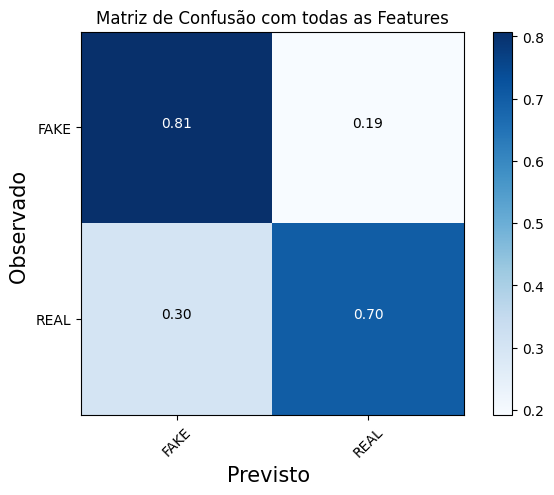

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn import tree

dt_classifier = DecisionTreeClassifier(max_depth=3)
dt_classifier.fit(tfidf_train, y_train)
pred = dt_classifier.predict(tfidf_test)

score = accuracy_score(y_test, pred)
print("Acurácia: ", score, "\n")

cm = confusion_matrix(y_test, pred, labels=["FAKE", "REAL"])
print("Matriz de confusão\n", cm, "\n")

plot_confusion_matrix(cm, classes=["FAKE", "REAL"], normalize=True,
                      title="Matriz de Confusão com todas as Features")

text_representation = tree.export_text(dt_classifier)
print(text_representation, "\n")


# Interpretando o Modelo

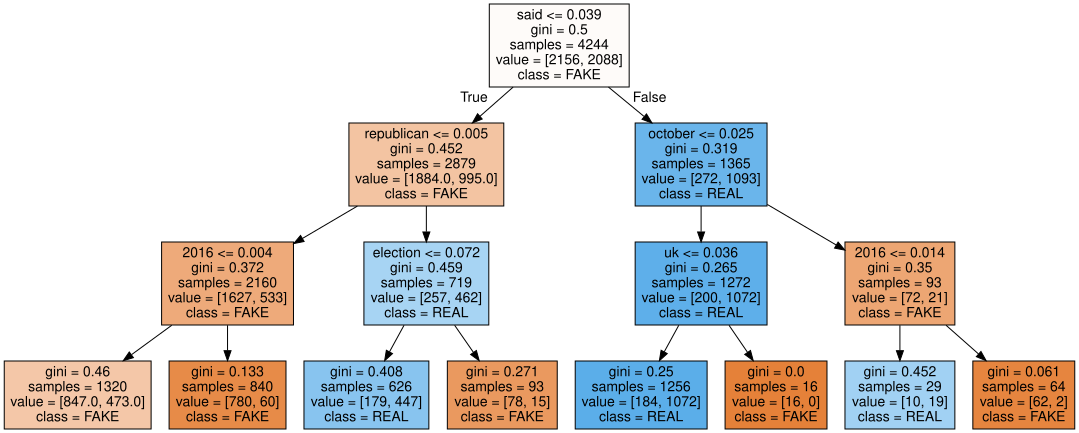

In [19]:
import graphviz
dot_data = tree.export_graphviz(dt_classifier, out_file=None,
                                feature_names=tfidf_vectorizer.get_feature_names_out(),
                                class_names=["FAKE", "REAL"],
                                filled=True)
graph = graphviz.Source(dot_data, format="png")
graph